# Method 3: API + Smoothed Time-bin Median Residual

This method improves `API + Time-bin Median Residual` by shrinking each time-bin median residual toward the global train median residual.

```text
smoothed_residual_bin = w * bin_residual + (1 - w) * global_residual
w = bin_count / (bin_count + k)
corrected_eta_secs = api_eta_secs + smoothed_residual_bin
```

Why this helps: bins with few samples can have noisy medians. A small `bin_count` produces a smaller `w`, so the correction falls back closer to the global residual. `k=0` is equivalent to the unsmoothed time-bin median method.

## Setup

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 140)
pd.set_option("display.float_format", "{:.3f}".format)

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
K_CANDIDATES = [0, 1, 2, 5, 10, 20, 30, 50, 75, 100, 150, 200]
PRIMARY_SELECTION_METRIC = "mae"


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "output_log.csv").exists():
            return candidate
    raise FileNotFoundError("Could not find data/output_log.csv from the current working directory.")


PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "output_log.csv"
ARTIFACT_DIR = PROJECT_ROOT / "residual_modeling" / "artifacts"

DATA_PATH

WindowsPath('D:/vinAI/GSM/Map/ETA-prediction/data/output_log.csv')

## Load and validate data

In [2]:
required_columns = {
    "stationId",
    "destination_stationId",
    "hour",
    "lat",
    "lng",
    "destination_lat",
    "destination_lng",
    "delta_time",
    "estimate_time",
    "timestamp",
}

raw_df = pd.read_csv(DATA_PATH)
missing_columns = sorted(required_columns - set(raw_df.columns))
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

df = raw_df.copy()
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

numeric_columns = ["delta_time", "estimate_time", "hour", "lat", "lng", "destination_lat", "destination_lng"]
for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

invalid_mask = (
    df["timestamp"].isna()
    | df["delta_time"].isna()
    | df["estimate_time"].isna()
    | (df["delta_time"] <= 0)
    | (df["estimate_time"] < 0)
)
if invalid_mask.any():
    print(f"Dropping {int(invalid_mask.sum())} invalid rows.")
    df = df.loc[~invalid_mask].copy()

df = df.sort_values("timestamp").reset_index(drop=True)
df["api_eta_secs"] = df["estimate_time"].astype(float)
df["actual_eta_secs"] = df["delta_time"].astype(float)
df["residual_secs"] = df["actual_eta_secs"] - df["api_eta_secs"]
df["od_pair"] = df["stationId"].astype(str) + "->" + df["destination_stationId"].astype(str)

data_summary = pd.DataFrame(
    {
        "rows": [len(df)],
        "timestamp_min": [df["timestamp"].min()],
        "timestamp_max": [df["timestamp"].max()],
        "unique_od_pairs": [df["od_pair"].nunique()],
        "actual_mean_secs": [df["actual_eta_secs"].mean()],
        "api_eta_mean_secs": [df["api_eta_secs"].mean()],
        "residual_median_secs": [df["residual_secs"].median()],
        "residual_mean_secs": [df["residual_secs"].mean()],
    }
)
data_summary

,rows,timestamp_min,timestamp_max,unique_od_pairs,actual_mean_secs,api_eta_mean_secs,residual_median_secs,residual_mean_secs
0,308,2026-01-01 05:23:27,2026-03-30 18:21:39,1,188.479,157.662,15.406,30.817


## Time bins and chronological split

In [3]:
TIME_BIN_ORDER = ["early_morning", "morning_peak", "off_peak_day", "evening_peak", "late_evening", "other"]


def assign_time_bin(hour: float | int) -> str:
    if pd.isna(hour):
        return "other"
    hour = int(hour)
    if 4 <= hour <= 6:
        return "early_morning"
    if 7 <= hour <= 9:
        return "morning_peak"
    if 10 <= hour <= 14:
        return "off_peak_day"
    if 15 <= hour <= 18:
        return "evening_peak"
    if 19 <= hour <= 21:
        return "late_evening"
    return "other"


def chronological_split(frame: pd.DataFrame, train_ratio: float = TRAIN_RATIO, val_ratio: float = VAL_RATIO):
    if train_ratio + val_ratio >= 1:
        raise ValueError("train_ratio + val_ratio must be < 1.")
    n_rows = len(frame)
    train_end = int(n_rows * train_ratio)
    val_end = int(n_rows * (train_ratio + val_ratio))
    return (
        frame.iloc[:train_end].copy(),
        frame.iloc[train_end:val_end].copy(),
        frame.iloc[val_end:].copy(),
    )


df["time_bin"] = df["hour"].map(assign_time_bin)
train_df, val_df, test_df = chronological_split(df)

split_summary = pd.DataFrame(
    [
        {"split": name, "rows": len(frame), "timestamp_min": frame["timestamp"].min(), "timestamp_max": frame["timestamp"].max()}
        for name, frame in [("train", train_df), ("val", val_df), ("test", test_df)]
    ]
)
split_summary

,split,rows,timestamp_min,timestamp_max
0,train,215,2026-01-01 05:23:27,2026-03-14 08:24:30
1,val,46,2026-03-14 09:06:41,2026-03-23 14:10:14
2,test,47,2026-03-23 15:07:42,2026-03-30 18:21:39


## Fit train residual tables

In [4]:
global_median_residual_secs = float(train_df["residual_secs"].median())
global_mean_residual_secs = float(train_df["residual_secs"].mean())

raw_time_bin_stats = (
    train_df.groupby("time_bin", observed=True)
    .agg(
        train_rows=("residual_secs", "size"),
        median_residual_secs=("residual_secs", "median"),
        mean_residual_secs=("residual_secs", "mean"),
        p25_residual_secs=("residual_secs", lambda values: float(np.percentile(values, 25))),
        p75_residual_secs=("residual_secs", lambda values: float(np.percentile(values, 75))),
    )
    .reindex(TIME_BIN_ORDER)
)
raw_time_bin_stats["fallback_used_when_missing"] = raw_time_bin_stats["median_residual_secs"].isna()
raw_time_bin_stats["median_residual_secs"] = raw_time_bin_stats["median_residual_secs"].fillna(global_median_residual_secs)
raw_time_bin_stats["train_rows"] = raw_time_bin_stats["train_rows"].fillna(0).astype(int)

raw_time_bin_stats

,train_rows,median_residual_secs,mean_residual_secs,p25_residual_secs,p75_residual_secs,fallback_used_when_missing
time_bin,,,,,,
early_morning,29,1.709,12.360,-23.916,33.314,False
morning_peak,30,20.922,36.957,-4.836,52.489,False
off_peak_day,35,5.807,13.637,-17.990,25.631,False
evening_peak,116,24.814,42.809,-4.160,62.476,False
late_evening,5,-11.770,-21.659,-44.965,-1.775,False
other,0,15.795,NaN,NaN,NaN,True


## Select smoothing strength on validation

`k` controls how much each bin is trusted. Larger `k` means stronger shrinkage toward the global median. We choose `k` on validation MAE, then evaluate the selected value once on test.

In [5]:
def smooth_time_bin_table(raw_stats: pd.DataFrame, global_residual: float, k: float) -> pd.DataFrame:
    table = raw_stats.copy()
    n = table["train_rows"].astype(float)
    if k < 0:
        raise ValueError("k must be non-negative.")
    if k == 0:
        weight = pd.Series(np.where(n > 0, 1.0, 0.0), index=table.index)
    else:
        weight = n / (n + float(k))
    table["k"] = float(k)
    table["shrinkage_weight"] = weight.astype(float)
    table["global_median_residual_secs"] = float(global_residual)
    table["smoothed_residual_secs"] = (
        table["shrinkage_weight"] * table["median_residual_secs"]
        + (1.0 - table["shrinkage_weight"]) * float(global_residual)
    )
    table.loc[table["train_rows"].eq(0), "smoothed_residual_secs"] = float(global_residual)
    return table


def regression_metrics(y_true: pd.Series | np.ndarray, y_pred: pd.Series | np.ndarray) -> dict[str, float]:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    abs_error = np.abs(y_true - y_pred)
    denom = np.maximum(np.abs(y_true), 1e-9)
    ss_res = float(np.sum((y_true - y_pred) ** 2))
    ss_tot = float(np.sum((y_true - np.mean(y_true)) ** 2))
    return {
        "mae": float(np.mean(abs_error)),
        "rmse": float(np.sqrt(np.mean((y_true - y_pred) ** 2))),
        "mape": float(np.mean(abs_error / denom) * 100.0),
        "median_absolute_error": float(np.median(abs_error)),
        "p50": float(np.percentile(abs_error, 50)),
        "p90": float(np.percentile(abs_error, 90)),
        "p95": float(np.percentile(abs_error, 95)),
        "r2": float(1.0 - ss_res / ss_tot) if ss_tot > 0 else float("nan"),
    }


def predict_with_residual_map(frame: pd.DataFrame, residual_map: dict[str, float], fallback_residual: float) -> pd.Series:
    residual = frame["time_bin"].map(residual_map).fillna(fallback_residual).astype(float)
    return frame["api_eta_secs"] + residual


def evaluate_prediction(frame: pd.DataFrame, pred_eta: pd.Series | np.ndarray) -> dict[str, float]:
    return regression_metrics(frame["actual_eta_secs"], pred_eta)


search_rows = []
for k in K_CANDIDATES:
    table = smooth_time_bin_table(raw_time_bin_stats, global_median_residual_secs, k)
    residual_map = table["smoothed_residual_secs"].to_dict()
    val_pred = predict_with_residual_map(val_df, residual_map, global_median_residual_secs)
    val_metrics = evaluate_prediction(val_df, val_pred)
    search_rows.append({"k": k, **{f"val_{key}": value for key, value in val_metrics.items()}})

smoothing_search_df = pd.DataFrame(search_rows)
best_row = smoothing_search_df.sort_values([f"val_{PRIMARY_SELECTION_METRIC}", "val_p95", "k"]).iloc[0]
best_k = float(best_row["k"])

smoothing_search_df.round(3)

,k,val_mae,val_rmse,val_mape,val_median_absolute_error,val_p50,val_p90,val_p95,val_r2
0,0,58.338,118.508,27.719,39.162,39.162,93.232,112.875,-0.077
1,1,58.342,118.511,27.734,39.218,39.218,93.055,112.863,-0.077
2,2,58.345,118.514,27.747,39.272,39.272,92.886,112.855,-0.077
3,5,58.352,118.525,27.781,39.420,39.420,92.421,112.292,-0.077
4,10,58.357,118.549,27.823,39.632,39.632,91.764,111.321,-0.077
5,20,58.355,118.605,27.870,40.080,40.080,90.753,109.908,-0.078
6,30,58.345,118.660,27.890,40.105,40.105,90.000,108.930,-0.079
7,50,58.345,118.759,27.909,39.223,39.223,88.936,107.665,-0.081
8,75,58.343,118.860,27.909,39.168,39.168,88.056,106.730,-0.083
9,100,58.336,118.940,27.899,39.190,39.190,87.445,106.142,-0.084


In [6]:
selected_smoothed_time_bin_stats = smooth_time_bin_table(raw_time_bin_stats, global_median_residual_secs, best_k)
selected_residual_map = selected_smoothed_time_bin_stats["smoothed_residual_secs"].to_dict()

selected_summary = pd.DataFrame(
    {
        "selected_k": [best_k],
        "selection_metric": [PRIMARY_SELECTION_METRIC],
        "validation_mae": [float(best_row["val_mae"])],
        "validation_p95": [float(best_row["val_p95"])],
        "global_median_residual_secs": [global_median_residual_secs],
    }
)
selected_summary

,selected_k,selection_metric,validation_mae,validation_p95,global_median_residual_secs
0,100.000,mae,58.336,106.142,15.795


In [7]:
selected_smoothed_time_bin_stats

,train_rows,median_residual_secs,mean_residual_secs,p25_residual_secs,p75_residual_secs,fallback_used_when_missing,k,shrinkage_weight,global_median_residual_secs,smoothed_residual_secs
time_bin,,,,,,,,,,
early_morning,29,1.709,12.360,-23.916,33.314,False,100.000,0.225,15.795,12.629
morning_peak,30,20.922,36.957,-4.836,52.489,False,100.000,0.231,15.795,16.978
off_peak_day,35,5.807,13.637,-17.990,25.631,False,100.000,0.259,15.795,13.206
evening_peak,116,24.814,42.809,-4.160,62.476,False,100.000,0.537,15.795,20.639
late_evening,5,-11.770,-21.659,-44.965,-1.775,False,100.000,0.048,15.795,14.483
other,0,15.795,NaN,NaN,NaN,True,100.000,0.000,15.795,15.795


## Predict all splits

In [8]:
raw_time_bin_residual_map = raw_time_bin_stats["median_residual_secs"].to_dict()

for split_df in [train_df, val_df, test_df]:
    split_df["api_baseline_eta_secs"] = split_df["api_eta_secs"]
    split_df["global_corrected_eta_secs"] = split_df["api_eta_secs"] + global_median_residual_secs
    split_df["raw_time_bin_residual_secs"] = split_df["time_bin"].map(raw_time_bin_residual_map).fillna(global_median_residual_secs)
    split_df["raw_time_bin_corrected_eta_secs"] = split_df["api_eta_secs"] + split_df["raw_time_bin_residual_secs"]
    split_df["smoothed_time_bin_residual_secs"] = split_df["time_bin"].map(selected_residual_map).fillna(global_median_residual_secs)
    split_df["smoothed_time_bin_corrected_eta_secs"] = split_df["api_eta_secs"] + split_df["smoothed_time_bin_residual_secs"]
    split_df["api_abs_error_secs"] = (split_df["actual_eta_secs"] - split_df["api_baseline_eta_secs"]).abs()
    split_df["global_abs_error_secs"] = (split_df["actual_eta_secs"] - split_df["global_corrected_eta_secs"]).abs()
    split_df["raw_time_bin_abs_error_secs"] = (split_df["actual_eta_secs"] - split_df["raw_time_bin_corrected_eta_secs"]).abs()
    split_df["smoothed_time_bin_abs_error_secs"] = (split_df["actual_eta_secs"] - split_df["smoothed_time_bin_corrected_eta_secs"]).abs()

test_df[
    [
        "timestamp",
        "hour",
        "time_bin",
        "actual_eta_secs",
        "api_eta_secs",
        "raw_time_bin_corrected_eta_secs",
        "smoothed_time_bin_corrected_eta_secs",
        "raw_time_bin_abs_error_secs",
        "smoothed_time_bin_abs_error_secs",
    ]
].head(12)

,timestamp,hour,time_bin,actual_eta_secs,api_eta_secs,raw_time_bin_corrected_eta_secs,smoothed_time_bin_corrected_eta_secs,raw_time_bin_abs_error_secs,smoothed_time_bin_abs_error_secs
261,2026-03-23 15:07:42,15,evening_peak,136.422,145.610,170.424,166.249,34.002,29.827
262,2026-03-23 17:13:37,17,evening_peak,122.146,162.610,187.424,183.249,65.278,61.103
263,2026-03-23 18:06:04,18,evening_peak,191.931,175.610,200.424,196.249,8.493,4.318
264,2026-03-23 18:11:54,18,evening_peak,264.974,175.610,200.424,196.249,64.551,68.726
265,2026-03-23 19:00:37,19,late_evening,178.022,190.110,178.340,204.593,0.318,26.570
266,2026-03-24 04:42:16,4,early_morning,156.960,156.110,157.819,168.739,0.859,11.779
267,2026-03-24 05:41:49,5,early_morning,188.977,155.610,157.319,168.239,31.659,20.739
268,2026-03-24 06:35:21,6,early_morning,146.279,127.610,129.319,140.239,16.960,6.040
269,2026-03-24 07:10:39,7,morning_peak,197.943,146.610,167.532,163.588,30.412,34.355
270,2026-03-24 10:53:58,10,off_peak_day,139.448,157.110,162.917,170.316,23.469,30.868


## Evaluation

Metrics are computed on final ETA seconds. Improvements are relative to raw API ETA within the same split.

In [9]:
def evaluate_method(split_name: str, frame: pd.DataFrame, method_name: str, prediction_column: str) -> dict[str, float | str | int]:
    api_metrics = regression_metrics(frame["actual_eta_secs"], frame["api_baseline_eta_secs"])
    method_metrics = regression_metrics(frame["actual_eta_secs"], frame[prediction_column])
    return {
        "split": split_name,
        "method": method_name,
        "rows": len(frame),
        "mae": method_metrics["mae"],
        "rmse": method_metrics["rmse"],
        "mape": method_metrics["mape"],
        "p50": method_metrics["p50"],
        "p90": method_metrics["p90"],
        "p95": method_metrics["p95"],
        "r2": method_metrics["r2"],
        "mae_improvement_vs_api_pct": (api_metrics["mae"] - method_metrics["mae"]) / api_metrics["mae"] * 100.0,
        "p95_improvement_vs_api_pct": (api_metrics["p95"] - method_metrics["p95"]) / api_metrics["p95"] * 100.0,
    }


evaluation_rows = []
for split_name, split_df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    evaluation_rows.append(evaluate_method(split_name, split_df, "api_eta", "api_baseline_eta_secs"))
    evaluation_rows.append(evaluate_method(split_name, split_df, "api_plus_global_median_residual", "global_corrected_eta_secs"))
    evaluation_rows.append(evaluate_method(split_name, split_df, "api_plus_raw_time_bin_median_residual", "raw_time_bin_corrected_eta_secs"))
    evaluation_rows.append(evaluate_method(split_name, split_df, "api_plus_smoothed_time_bin_median_residual", "smoothed_time_bin_corrected_eta_secs"))

metrics_df = pd.DataFrame(evaluation_rows)
metrics_df.round(3)

,split,method,rows,mae,rmse,mape,p50,p90,p95,r2,mae_improvement_vs_api_pct,p95_improvement_vs_api_pct
0,train,api_eta,215,50.385,79.118,22.950,32.381,108.377,173.988,-0.281,0.000,0.000
1,train,api_plus_global_median_residual,215,47.611,74.228,23.174,32.443,98.622,158.193,-0.127,5.505,9.078
2,train,api_plus_raw_time_bin_median_residual,215,46.295,72.503,22.588,30.808,97.015,150.342,-0.076,8.118,13.591
3,train,api_plus_smoothed_time_bin_median_residual,215,47.107,73.280,23.115,32.089,99.388,154.448,-0.099,6.507,11.231
4,val,api_eta,46,61.401,123.239,27.360,40.425,96.876,119.348,-0.164,0.000,0.000
5,val,api_plus_global_median_residual,46,58.623,119.594,27.895,41.099,83.729,103.552,-0.096,4.524,13.235
6,val,api_plus_raw_time_bin_median_residual,46,58.338,118.508,27.719,39.162,93.232,112.875,-0.077,4.988,5.423
7,val,api_plus_smoothed_time_bin_median_residual,46,58.336,118.940,27.899,39.190,87.445,106.142,-0.084,4.992,11.065
8,test,api_eta,47,37.956,56.887,18.344,23.079,84.593,123.750,0.034,0.000,0.000
9,test,api_plus_global_median_residual,47,37.249,52.804,19.578,30.098,68.797,107.954,0.168,1.862,12.764


In [10]:
test_metrics = metrics_df.loc[metrics_df["split"].eq("test")].copy()
test_metrics.sort_values("mae").round(3)

,split,method,rows,mae,rmse,mape,p50,p90,p95,r2,mae_improvement_vs_api_pct,p95_improvement_vs_api_pct
9,test,api_plus_global_median_residual,47,37.249,52.804,19.578,30.098,68.797,107.954,0.168,1.862,12.764
8,test,api_eta,47,37.956,56.887,18.344,23.079,84.593,123.750,0.034,0.000,0.000
10,test,api_plus_raw_time_bin_median_residual,47,37.965,51.794,20.452,32.085,64.841,98.936,0.199,-0.024,20.051
11,test,api_plus_smoothed_time_bin_median_residual,47,38.073,52.159,20.402,30.868,64.152,103.111,0.188,-0.307,16.678


## Diagnostics

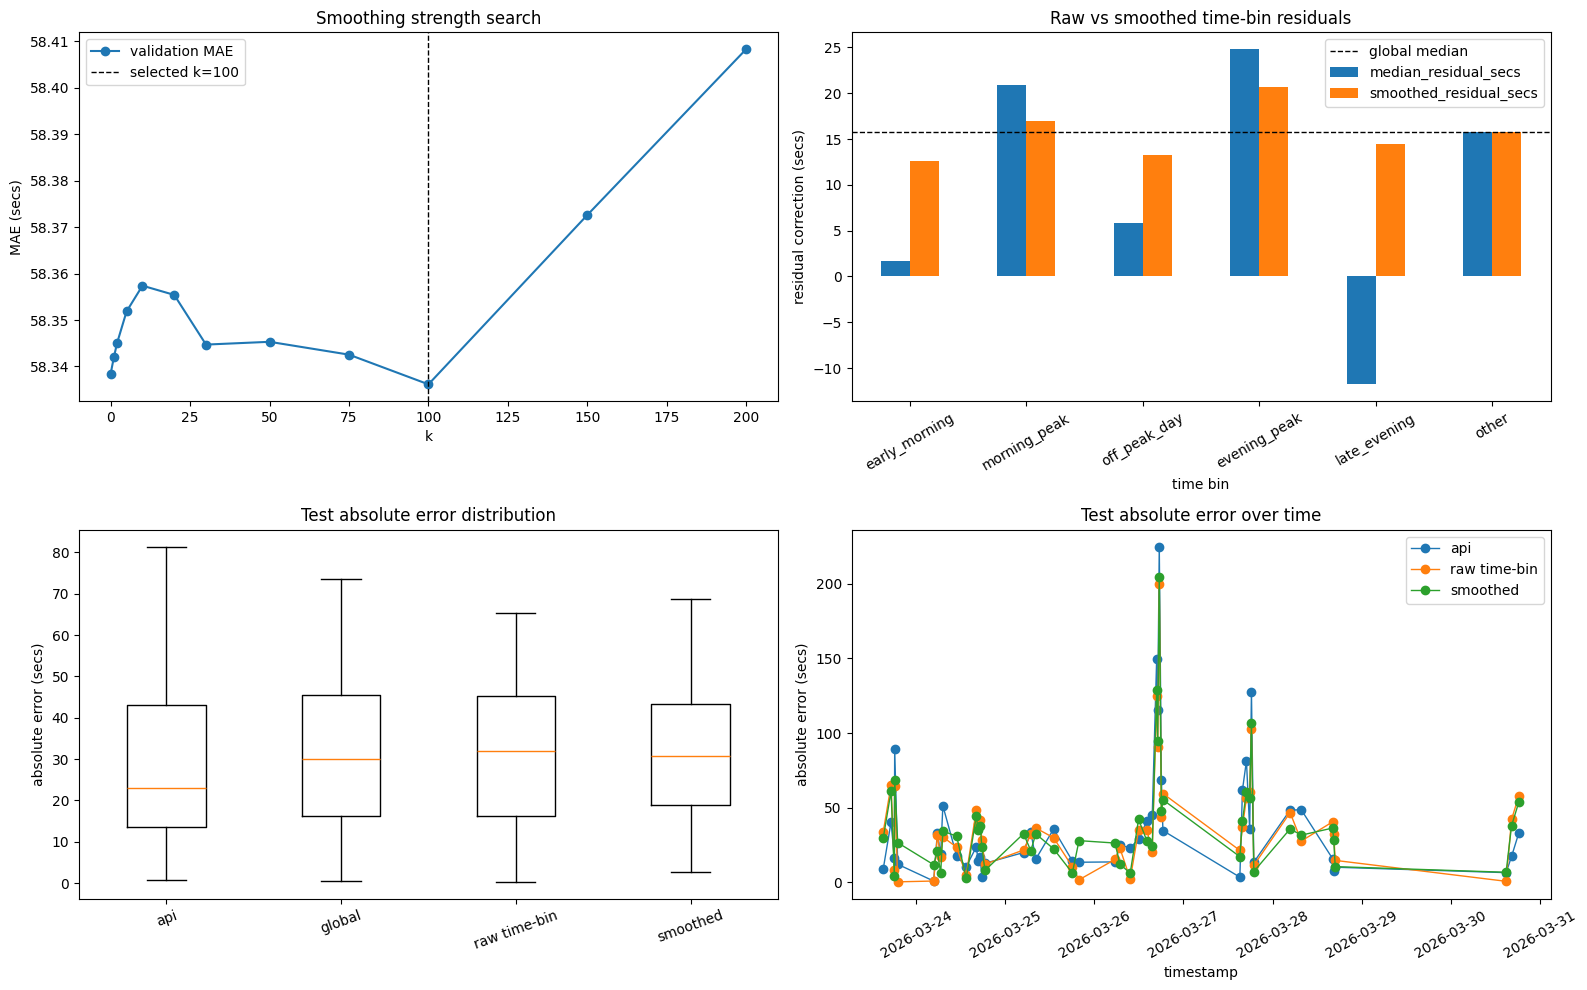

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].plot(smoothing_search_df["k"], smoothing_search_df["val_mae"], marker="o", label="validation MAE")
axes[0, 0].axvline(best_k, color="black", linestyle="--", linewidth=1, label=f"selected k={best_k:g}")
axes[0, 0].set_title("Smoothing strength search")
axes[0, 0].set_xlabel("k")
axes[0, 0].set_ylabel("MAE (secs)")
axes[0, 0].legend()

comparison_table = selected_smoothed_time_bin_stats[["median_residual_secs", "smoothed_residual_secs"]]
comparison_table.plot(kind="bar", ax=axes[0, 1])
axes[0, 1].axhline(global_median_residual_secs, color="black", linestyle="--", linewidth=1, label="global median")
axes[0, 1].set_title("Raw vs smoothed time-bin residuals")
axes[0, 1].set_xlabel("time bin")
axes[0, 1].set_ylabel("residual correction (secs)")
axes[0, 1].tick_params(axis="x", rotation=30)
axes[0, 1].legend()

box_cols = ["api_abs_error_secs", "global_abs_error_secs", "raw_time_bin_abs_error_secs", "smoothed_time_bin_abs_error_secs"]
box_labels = ["api", "global", "raw time-bin", "smoothed"]
axes[1, 0].boxplot([test_df[col].to_numpy() for col in box_cols], tick_labels=box_labels, showfliers=False)
axes[1, 0].set_title("Test absolute error distribution")
axes[1, 0].set_ylabel("absolute error (secs)")
axes[1, 0].tick_params(axis="x", rotation=20)

axes[1, 1].plot(test_df["timestamp"], test_df["api_abs_error_secs"], marker="o", linewidth=1, label="api")
axes[1, 1].plot(test_df["timestamp"], test_df["raw_time_bin_abs_error_secs"], marker="o", linewidth=1, label="raw time-bin")
axes[1, 1].plot(test_df["timestamp"], test_df["smoothed_time_bin_abs_error_secs"], marker="o", linewidth=1, label="smoothed")
axes[1, 1].set_title("Test absolute error over time")
axes[1, 1].set_xlabel("timestamp")
axes[1, 1].set_ylabel("absolute error (secs)")
axes[1, 1].tick_params(axis="x", rotation=30)
axes[1, 1].legend()

plt.tight_layout()

## Save reusable artifacts

In [12]:
def to_json_records(frame: pd.DataFrame) -> list[dict]:
    return frame.astype(object).where(pd.notna(frame), None).to_dict(orient="records")


ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

all_predictions = pd.concat(
    [
        train_df.assign(split="train"),
        val_df.assign(split="val"),
        test_df.assign(split="test"),
    ],
    ignore_index=True,
)

prediction_columns = [
    "split",
    "timestamp",
    "stationId",
    "destination_stationId",
    "hour",
    "time_bin",
    "api_eta_secs",
    "actual_eta_secs",
    "residual_secs",
    "global_corrected_eta_secs",
    "raw_time_bin_residual_secs",
    "raw_time_bin_corrected_eta_secs",
    "smoothed_time_bin_residual_secs",
    "smoothed_time_bin_corrected_eta_secs",
    "api_abs_error_secs",
    "global_abs_error_secs",
    "raw_time_bin_abs_error_secs",
    "smoothed_time_bin_abs_error_secs",
]

predictions_path = ARTIFACT_DIR / "method3_predictions.csv"
all_predictions[prediction_columns].to_csv(predictions_path, index=False)

smoothed_table_path = ARTIFACT_DIR / "method3_smoothed_time_bin_residuals.csv"
selected_smoothed_time_bin_stats.reset_index(names="time_bin").to_csv(smoothed_table_path, index=False)

smoothing_search_path = ARTIFACT_DIR / "method3_smoothing_search.csv"
smoothing_search_df.to_csv(smoothing_search_path, index=False)

model_card = {
    "notebook": "residual_modeling/method3.ipynb",
    "data_path": str(DATA_PATH.relative_to(PROJECT_ROOT)),
    "target": "actual_eta_secs",
    "api_eta_column": "estimate_time",
    "actual_column": "delta_time",
    "split_strategy": "chronological_70_15_15",
    "method": "api_plus_smoothed_time_bin_median_residual",
    "formula": "api_eta_secs + (w * time_bin_median_residual + (1 - w) * global_median_residual), w=n/(n+k)",
    "selected_k": best_k,
    "selection_metric": PRIMARY_SELECTION_METRIC,
    "k_candidates": K_CANDIDATES,
    "global_median_residual_secs": global_median_residual_secs,
    "global_mean_residual_secs": global_mean_residual_secs,
    "time_bins": {
        "early_morning": "4-6",
        "morning_peak": "7-9",
        "off_peak_day": "10-14",
        "evening_peak": "15-18",
        "late_evening": "19-21",
        "other": "outside configured bins",
    },
    "split_summary": split_summary.assign(
        timestamp_min=split_summary["timestamp_min"].astype(str),
        timestamp_max=split_summary["timestamp_max"].astype(str),
    ).to_dict(orient="records"),
    "time_bin_residuals": to_json_records(selected_smoothed_time_bin_stats.reset_index(names="time_bin")),
    "smoothing_search": to_json_records(smoothing_search_df),
    "metrics": to_json_records(metrics_df),
}

model_card_path = ARTIFACT_DIR / "method3_model_card.json"
model_card_path.write_text(json.dumps(model_card, indent=2, allow_nan=False), encoding="utf-8")

pd.DataFrame(
    {
        "artifact": ["model_card", "predictions", "smoothed_time_bin_residuals", "smoothing_search"],
        "path": [
            str(model_card_path.relative_to(PROJECT_ROOT)),
            str(predictions_path.relative_to(PROJECT_ROOT)),
            str(smoothed_table_path.relative_to(PROJECT_ROOT)),
            str(smoothing_search_path.relative_to(PROJECT_ROOT)),
        ],
    }
)

,artifact,path
0,model_card,residual_modeling\artifacts\method3_model_card...
1,predictions,residual_modeling\artifacts\method3_prediction...
2,smoothed_time_bin_residuals,residual_modeling\artifacts\method3_smoothed_t...
3,smoothing_search,residual_modeling\artifacts\method3_smoothing_...
